# Smart Parking Demand Prediction

This analysis identifies clear temporal and spatial parking demand patterns across Melbourne zones, showing that machine learning models can recover useful structure in the data, but the current baseline performance is moderate rather than deployment-ready.

**Authored by**: Shrikrishna Rai

**Duration**: 60 mins

**Level**: Intermediate

**Prerequisite Skills**: Python, Pandas, Matplotlib, scikit-learn

### Overview

This analysis provides a comprehensive assessment of hourly parking demand patterns across Melbourne's on-street parking zones. By integrating sensor data with restriction metadata, we quantify occupancy trends and develop predictive models to support parking management, pricing optimisation, and infrastructure planning decisions.

### Methodology

The analysis ingests historical parking sensor data and live occupancy records from Melbourne's open data platform, combines them with parking restriction information, and produces a normalised hourly demand dataset. Machine learning models (Logistic Regression and Random Forest) are applied to classify demand levels (Low, Medium, High) based on temporal and spatial features, with cross-validation and a temporal holdout used to estimate generalisation more realistically.

### Datasets used

All datasets are sourced from [Melbourne Open Data](https://data.melbourne.vic.gov.au/) and provide comprehensive coverage of on-street parking activities, restrictions, and bay status:

1. **[On-street Car Parking Sensor Data (2014)](https://data.melbourne.vic.gov.au/explore/dataset/on-street-car-parking-sensor-data/table/)** – Historical parking events collected from bay-level sensors deployed across Melbourne. Contains arrival and departure timestamps, device identifiers, duration of stay, and street information. This dataset provides granular temporal patterns of parking occupancy throughout 2014, enabling analysis of demand by hour, day, and location.

2. **[Parking Bay Arrivals and Departures (2014)](https://data.melbourne.vic.gov.au/explore/dataset/on-street-parking-bay-sensors/table/)** – Event-level records of individual parking bay occupancy transitions. Captures each arrival and departure event with precise timestamps and bay identifiers, complementing the sensor data with explicit state change information for more accurate occupancy calculations.

3. **[On-Street Parking Bay Sensors (Live)](https://data.melbourne.vic.gov.au/explore/dataset/on-street-parking-bay-sensors/table/)** – Real-time API endpoint providing current occupancy status of parking bays across Melbourne's CBD and surrounding areas. Includes bay status (Present/Absent), last update timestamp, kerbside identifiers, and location coordinates (latitude/longitude). Updated dynamically to reflect current bay availability.

4. **[Sign Plates Located in Each Parking Zone](https://data.melbourne.vic.gov.au/explore/dataset/sign-plates-located-in-each-parking-zone/information/)** – Parking restriction metadata including zone numbers, restriction types (e.g. 2P, 4P, permit-only, disabled), time restrictions, and zone coordinates. This dataset enables spatial analysis and linking restrictions to occupancy patterns.

### Data Processing and Analysis Pipeline

The following sections execute the complete workflow: data ingestion from Melbourne Open Data sources, cleaning and standardisation, feature engineering for temporal and spatial analysis, exploratory data analysis, and machine learning model development with performance validation.

In [43]:
import matplotlib.pyplot as plt  
import numpy as np
import pandas as pd  
import requests  
import zipfile 
from pathlib import Path  

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
 )
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import ast
import json
import folium
from folium.plugins import MarkerCluster
from IPython.display import HTML
from sklearn.dummy import DummyClassifier


In [44]:
# Resolve data paths from the notebook folder when possible so the ingestion
# cells behave consistently in Jupyter, VS Code, and nbconvert.
USECASE_NOTEBOOK = "UC00232_Smart_Parking_Demand_Prediction.ipynb"
USECASE_DIR = Path.cwd()

if not (USECASE_DIR / USECASE_NOTEBOOK).exists():
    matches = list(Path.cwd().rglob(USECASE_NOTEBOOK))
    if matches:
        USECASE_DIR = matches[0].parent

DATA_DIR = USECASE_DIR.parent / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
CACHE_DIR = DATA_DIR / "cache"
PROCESSED_DIR = DATA_DIR / "processed"

for directory in [RAW_DATA_DIR, CACHE_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Remote datasets used in this notebook.
CAR_PARKING_DATA_ZIP_URL = "https://opendatasoft-s3.s3.amazonaws.com/downloads/archive/t6hb-9uf2.zip"
PARKING_BAY_DATA_ZIP_URL = "https://opendatasoft-s3.s3.amazonaws.com/downloads/archive/mq3i-cbxd.zip"


def load_melbourne_api(dataset_slug, rows=5000, use_cache=True):
    """Load a Melbourne Open Data API dataset into a DataFrame."""
    url = "https://data.melbourne.vic.gov.au/api/records/1.0/search/"
    params = {"dataset": dataset_slug, "rows": rows}
    cache_file = CACHE_DIR / f"{dataset_slug}.json"
    data = None

    if use_cache and cache_file.exists():
        with cache_file.open("r", encoding="utf-8") as fh:
            data = json.load(fh)
    else:
        try:
            response = requests.get(url, params=params, timeout=60)
            response.raise_for_status()
            data = response.json()
            if use_cache:
                with cache_file.open("w", encoding="utf-8") as fh:
                    json.dump(data, fh)
        except (requests.RequestException, ValueError) as exc:
            if cache_file.exists():
                with cache_file.open("r", encoding="utf-8") as fh:
                    data = json.load(fh)
            else:
                raise RuntimeError(
                    f"Unable to load '{dataset_slug}' from Melbourne Open Data, and no local cache was found at {cache_file}."
                ) from exc

    records = data.get("records", []) if data else []
    if not records:
        raise RuntimeError(
            f"The Melbourne Open Data response for '{dataset_slug}' did not contain records. Check the dataset slug or cache file."
        )

    return pd.DataFrame([record.get("fields", {}) for record in records])


def download_file(url, destination):
    """Download a file and save it to the local cache."""
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    with destination.open("wb") as output_file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                output_file.write(chunk)

    return destination


def read_cached_zip_csv(zip_url, cache_name, nrows=None):
    """Return the first CSV inside a cached zip, downloading it if required."""
    cache_path = RAW_DATA_DIR / cache_name

    if not cache_path.exists():
        try:
            download_file(zip_url, cache_path)
        except requests.RequestException as exc:
            raise RuntimeError(
                f"Unable to download {cache_name}. Place the zip file in {RAW_DATA_DIR} or re-run with network access."
            ) from exc

    try:
        archive = zipfile.ZipFile(cache_path)
    except zipfile.BadZipFile as exc:
        raise RuntimeError(f"The cached file is not a valid zip archive: {cache_path}") from exc

    with archive:
        csv_member = next(
            (name for name in archive.namelist() if name.lower().endswith(".csv")),
            None,
        )

        if csv_member is None:
            raise ValueError(f"No CSV file found inside {cache_path.name}")

        with archive.open(csv_member) as csv_file:
            df = pd.read_csv(csv_file, nrows=nrows, low_memory=False)
            for _col in ["StreetId", "BetweenStreet1 Id", "BetweenStreet2 Id"]:
                if _col in df.columns:
                    df[_col] = df[_col].astype(str)
            return df

print(f"Using data directory: {DATA_DIR}")

Using data directory: /home/shree/Desktop/MOP-Code/datascience/usecases/READY TO PUBLISH/Transport_and_Mobility/2026/T1/data


## Data Ingestion

This section downloads the Melbourne Open Data sources when they are not already cached locally, then loads each dataset into a pandas DataFrame. The cache keeps the notebook reproducible and reduces pressure on the remote API, while the row limits keep the workflow responsive enough to run interactively.

The ingestion step also acts as an early validation point. If a dataset cannot be fetched, the notebook falls back to a cached copy where possible and raises a clear error when neither source is available. The data directory is resolved from the notebook location so the same relative paths work in Jupyter, VS Code, and automated execution.

This matters because the rest of the analysis depends on four separate sources: live bay status, parking-zone restrictions, historical sensor events, and arrival/departure records. Catching missing or empty inputs here prevents harder-to-debug errors later in cleaning, mapping, or model training.

In [45]:
# Load datasets. The first run may take time while the two zip files are cached.
on_street_parking_bay_sensor_df = load_melbourne_api("on-street-parking-bay-sensors", rows=5000)

sign_plates_located_in_parking_bays_df = load_melbourne_api(
    "sign-plates-located-in-each-parking-zone",
    rows=5000,
)

on_street_car_parking_sensor_df = read_cached_zip_csv(
    CAR_PARKING_DATA_ZIP_URL,
    "On-street_Car_Parking_Sensor_Data_-_2014.zip",
    nrows=300000,
)

parking_bay_arrivals_and_departures_df = read_cached_zip_csv(
    PARKING_BAY_DATA_ZIP_URL,
    "Parking_bay_arrivals_and_departures_2014.zip",
    nrows=300000,
)

loaded_datasets = {
    "live bay sensors": on_street_parking_bay_sensor_df,
    "parking zone sign plates": sign_plates_located_in_parking_bays_df,
    "2014 car parking sensor events": on_street_car_parking_sensor_df,
    "2014 bay arrivals and departures": parking_bay_arrivals_and_departures_df,
}

empty_datasets = [name for name, df in loaded_datasets.items() if df.empty]
if empty_datasets:
    raise RuntimeError(f"The following datasets loaded with no rows: {empty_datasets}")

for name, df in loaded_datasets.items():
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

live bay sensors: 3,309 rows, 6 columns
parking zone sign plates: 2,033 rows, 5 columns
2014 car parking sensor events: 300,000 rows, 14 columns
2014 bay arrivals and departures: 300,000 rows, 21 columns


### Initial Dataset Checks

Preview each raw dataset, inspect the column names, and check the inferred data types before cleaning. These checks make schema differences visible early.


In [46]:
print("**on_street_car_parking_sensor_df**")
print(on_street_car_parking_sensor_df.head())
print(on_street_car_parking_sensor_df.columns)
on_street_car_parking_sensor_df.info()

**on_street_car_parking_sensor_df**
  DeviceId             ArrivalTime           DepartureTime DurationSeconds StreetMarker                       Sign  \
0   10,032  07/01/2014 11:43:23 AM  07/01/2014 11:43:30 AM               7        3273S      1P MTR M-F 9:30-19:30   
1   11,649  03/19/2014 10:09:38 AM  03/19/2014 10:11:22 AM             104        2206N  1/2P MTR M-SAT 7:30-19:30   
2    9,126  06/12/2014 07:30:00 AM  06/12/2014 10:17:23 AM          10,043       11921W      2P MTR M-F 7:30-18:30   
3   12,462  07/02/2014 07:30:11 AM  07/02/2014 07:34:11 AM             240        2418N       1/4P M-SAT 7:30-9:30   
4   14,588  07/16/2014 08:12:00 AM  07/16/2014 08:12:14 AM              14       13749W  2P TKT A M-SAT 7:30-18:30   

             Area StreetId         StreetName   BetweenStreet1      BetweenStreet2  Side Of Street  In Violation  \
0          County      894    LONSDALE STREET      KING STREET      WILLIAM STREET             4.0         False   
1        McKillop      

In [47]:
print("**on_street_parking_bay_sensor_df**")
print(on_street_parking_bay_sensor_df.head())
print(on_street_parking_bay_sensor_df.columns)
on_street_parking_bay_sensor_df.info()

**on_street_parking_bay_sensor_df**
            status_timestamp  zone_number                lastupdated  kerbsideid status_description  \
0  2024-08-18T08:23:46+00:00       7394.0  2024-12-30T00:44:37+00:00        9344         Unoccupied   
1  2024-08-14T09:22:05+00:00       7392.0  2025-01-10T02:44:36+00:00        9373         Unoccupied   
2  2024-11-28T02:30:57+00:00       7084.0  2024-12-04T23:44:37+00:00        8735            Present   
3  2024-11-27T23:23:40+00:00       7084.0  2024-12-04T23:44:37+00:00        8749         Unoccupied   
4  2023-08-21T00:09:03+00:00       7800.0  2025-01-09T05:44:36+00:00       24505            Present   

                                   location  
0  [-37.80494402936792, 144.95916129121264]  
1  [-37.80329074425858, 144.95836336946644]  
2  [-37.80223335664963, 144.96120480793184]  
3   [-37.80230361629087, 144.9618505999636]  
4  [-37.79756250415984, 144.95759881813447]  
Index(['status_timestamp', 'zone_number', 'lastupdated', 'kerbsideid'

In [48]:
print("**parking_bay_arrivals_and_departures_df**")
print(parking_bay_arrivals_and_departures_df.head())
print(parking_bay_arrivals_and_departures_df.columns)
parking_bay_arrivals_and_departures_df.info()

**parking_bay_arrivals_and_departures_df**
  ParkingEventId DeviceId                   ArrivalTime                 DepartureTime DurationSeconds StreetMarker  \
0          3,123   11,710  04/02/2014 10:56:29 AM +0000  04/02/2014 11:06:08 AM +0000             600        6588N   
1          3,124   11,710  04/02/2014 11:07:23 AM +0000  04/02/2014 11:38:48 AM +0000           1,860        6588N   
2          3,125   11,710  04/02/2014 12:09:59 PM +0000  04/02/2014 12:34:30 PM +0000           1,500        6588N   
3          3,126   11,710  04/02/2014 12:39:30 PM +0000  04/02/2014 12:58:07 PM +0000           1,140        6588N   
4          3,129   11,710  04/02/2014 01:08:46 PM +0000  04/02/2014 01:14:46 PM +0000             360        6588N   

   SignPlateId                     Sign  Area         AreaName StreetId       StreetName BetweenStreet1 Id  \
0            6  1P MTR M-SAT 7:30-19:30    12  Victoria Market      681  FRANKLIN STREET             1,171   
1            6  1P MTR M-SAT

In [49]:
print("**sign_plates_located_in_parking_bays_df**")
print(sign_plates_located_in_parking_bays_df.head())
print(sign_plates_located_in_parking_bays_df.columns)
sign_plates_located_in_parking_bays_df.info()

**sign_plates_located_in_parking_bays_df**
  restriction_display  parkingzone time_restrictions_start restriction_days time_restrictions_finish
0                  2P         7001                07:30:00              Sat                 12:30:00
1                  2P         7007                07:30:00              Sat                 12:30:00
2                  2P         7025                07:30:00          Mon-Fri                 18:30:00
3                  2P         7025                07:30:00              Sat                 12:30:00
4                  HP         7019                07:30:00              Sat                 12:30:00
Index(['restriction_display', 'parkingzone', 'time_restrictions_start', 'restriction_days',
       'time_restrictions_finish'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2033 entries, 0 to 2032
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0 

## Data Cleaning and Preparation

The raw sources use different naming conventions and data formats. The next cells standardise column names, remove duplicate rows, convert numeric and datetime fields, and drop records that are missing fields required for demand analysis.


In [50]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

on_street_car_parking_sensor_df = clean_column_names(on_street_car_parking_sensor_df)
on_street_parking_bay_sensor_df = clean_column_names(on_street_parking_bay_sensor_df)
parking_bay_arrivals_and_departures_df = clean_column_names(parking_bay_arrivals_and_departures_df)
sign_plates_located_in_parking_bays_df = clean_column_names(sign_plates_located_in_parking_bays_df)

In [51]:
print("on_street_car_parking_sensor_df columns:")
print(on_street_car_parking_sensor_df.columns.tolist())

print("\non_street_parking_bay_sensor_df columns:")
print(on_street_parking_bay_sensor_df.columns.tolist())

print("\nparking_bay_arrivals_and_departures_df columns:")
print(parking_bay_arrivals_and_departures_df.columns.tolist())

print("\nsign_plates_located_in_parking_bays_df columns:")
print(sign_plates_located_in_parking_bays_df.columns.tolist())

on_street_car_parking_sensor_df columns:
['deviceid', 'arrivaltime', 'departuretime', 'durationseconds', 'streetmarker', 'sign', 'area', 'streetid', 'streetname', 'betweenstreet1', 'betweenstreet2', 'side_of_street', 'in_violation', 'vehicle_present']

on_street_parking_bay_sensor_df columns:
['status_timestamp', 'zone_number', 'lastupdated', 'kerbsideid', 'status_description', 'location']

parking_bay_arrivals_and_departures_df columns:
['parkingeventid', 'deviceid', 'arrivaltime', 'departuretime', 'durationseconds', 'streetmarker', 'signplateid', 'sign', 'area', 'areaname', 'streetid', 'streetname', 'betweenstreet1_id', 'betweenstreet1_description', 'betweenstreet2_id', 'betweenstreet2_description', 'sideofstreet', 'sidecode', 'sidename', 'bayid', 'inviolation']

sign_plates_located_in_parking_bays_df columns:
['restriction_display', 'parkingzone', 'time_restrictions_start', 'restriction_days', 'time_restrictions_finish']


In [52]:
on_street_car_parking_sensor_df = on_street_car_parking_sensor_df.drop_duplicates()
on_street_parking_bay_sensor_df["location"] = (
    on_street_parking_bay_sensor_df["location"].apply(
        lambda value: tuple(value) if isinstance(value, list) else value
    )
)
on_street_parking_bay_sensor_df = on_street_parking_bay_sensor_df.drop_duplicates()
parking_bay_arrivals_and_departures_df = parking_bay_arrivals_and_departures_df.drop_duplicates()
sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.drop_duplicates()

### Numeric and Datetime Normalisation

Some downloaded CSV fields include comma-formatted numbers or date strings. These cells convert them into numeric and datetime types so pandas can group, filter, and model them correctly.


In [53]:
# Remove comma separators from 2014 sensor identifiers and durations
on_street_car_parking_sensor_df["deviceid"] = (
    on_street_car_parking_sensor_df["deviceid"].astype(str).str.replace(",", "", regex=False)
)
on_street_car_parking_sensor_df["streetid"] = (
    on_street_car_parking_sensor_df["streetid"].astype(str).str.replace(",", "", regex=False)
)
on_street_car_parking_sensor_df["durationseconds"] = (
    on_street_car_parking_sensor_df["durationseconds"].astype(str).str.replace(",", "", regex=False)
)

# Remove comma separators from arrivals/departures identifiers and durations
parking_bay_arrivals_and_departures_df["parkingeventid"] = (
    parking_bay_arrivals_and_departures_df["parkingeventid"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["deviceid"] = (
    parking_bay_arrivals_and_departures_df["deviceid"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["durationseconds"] = (
    parking_bay_arrivals_and_departures_df["durationseconds"].astype(str).str.replace(",", "", regex=False)
)
parking_bay_arrivals_and_departures_df["bayid"] = (
    parking_bay_arrivals_and_departures_df["bayid"].astype(str).str.replace(",", "", regex=False)
)

In [54]:
on_street_car_parking_sensor_df["deviceid"] = pd.to_numeric(on_street_car_parking_sensor_df["deviceid"], errors="coerce")
on_street_car_parking_sensor_df["streetid"] = pd.to_numeric(on_street_car_parking_sensor_df["streetid"], errors="coerce")
on_street_car_parking_sensor_df["durationseconds"] = pd.to_numeric(on_street_car_parking_sensor_df["durationseconds"], errors="coerce")

parking_bay_arrivals_and_departures_df["parkingeventid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["parkingeventid"], errors="coerce")
parking_bay_arrivals_and_departures_df["deviceid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["deviceid"], errors="coerce")
parking_bay_arrivals_and_departures_df["durationseconds"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["durationseconds"], errors="coerce")
parking_bay_arrivals_and_departures_df["bayid"] = pd.to_numeric(parking_bay_arrivals_and_departures_df["bayid"], errors="coerce")

In [55]:
on_street_car_parking_sensor_df["arrivaltime"] = pd.to_datetime(
    on_street_car_parking_sensor_df["arrivaltime"],
    errors="coerce"
)

on_street_car_parking_sensor_df["departuretime"] = pd.to_datetime(
    on_street_car_parking_sensor_df["departuretime"],
    errors="coerce"
)

on_street_parking_bay_sensor_df["lastupdated"] = pd.to_datetime(
    on_street_parking_bay_sensor_df["lastupdated"],
    errors="coerce",
    utc=True
)

on_street_parking_bay_sensor_df["status_timestamp"] = pd.to_datetime(
    on_street_parking_bay_sensor_df["status_timestamp"],
    errors="coerce",
    utc=True
)

parking_bay_arrivals_and_departures_df["arrivaltime"] = pd.to_datetime(
    parking_bay_arrivals_and_departures_df["arrivaltime"],
    errors="coerce"
)

parking_bay_arrivals_and_departures_df["departuretime"] = pd.to_datetime(
    parking_bay_arrivals_and_departures_df["departuretime"],
    errors="coerce"
)

In [56]:
on_street_car_parking_sensor_df = on_street_car_parking_sensor_df.dropna(
    subset=["deviceid", "arrivaltime", "departuretime"]
)

on_street_parking_bay_sensor_df = on_street_parking_bay_sensor_df.dropna(
    subset=["status_timestamp", "status_description", "kerbsideid"]
)

parking_bay_arrivals_and_departures_df = parking_bay_arrivals_and_departures_df.dropna(
    subset=["deviceid", "arrivaltime", "departuretime", "bayid"]
)

sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.dropna(
    subset=["parkingzone"]
)

### Temporal Feature Engineering

Arrival and status timestamps are transformed into hour, day, month, and weekend indicators. These features capture the recurring time patterns that usually drive parking demand.


In [57]:
# Add temporal features from historical sensor arrivals
on_street_car_parking_sensor_df["arrival_hour"] = on_street_car_parking_sensor_df["arrivaltime"].dt.hour
on_street_car_parking_sensor_df["arrival_day"] = on_street_car_parking_sensor_df["arrivaltime"].dt.day_name()
on_street_car_parking_sensor_df["arrival_month"] = on_street_car_parking_sensor_df["arrivaltime"].dt.month
on_street_car_parking_sensor_df["is_weekend"] = on_street_car_parking_sensor_df["arrivaltime"].dt.dayofweek >= 5

# Add temporal features from live bay status timestamps
on_street_parking_bay_sensor_df["status_hour"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.hour
on_street_parking_bay_sensor_df["status_day"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.day_name()
on_street_parking_bay_sensor_df["status_month"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.month
on_street_parking_bay_sensor_df["is_weekend"] = on_street_parking_bay_sensor_df["status_timestamp"].dt.dayofweek >= 5

# Add temporal features from arrivals/departures timestamps
parking_bay_arrivals_and_departures_df["arrival_hour"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.hour
parking_bay_arrivals_and_departures_df["arrival_day"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.day_name()
parking_bay_arrivals_and_departures_df["arrival_month"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.month
parking_bay_arrivals_and_departures_df["is_weekend"] = parking_bay_arrivals_and_departures_df["arrivaltime"].dt.dayofweek >= 5

In [58]:
# Keep timestamps timezone-naive so they are easier to read and export
on_street_parking_bay_sensor_df["lastupdated"] = (
    on_street_parking_bay_sensor_df["lastupdated"].dt.tz_convert(None)
)

on_street_parking_bay_sensor_df["status_timestamp"] = (
    on_street_parking_bay_sensor_df["status_timestamp"].dt.tz_convert(None)
)

### Occupancy and Zone Metadata

Live bay status is converted into a binary occupancy flag, then joined with parking restriction metadata by zone. This creates the main analysis table used to calculate demand.


In [59]:
on_street_parking_bay_sensor_df["occupied"] = on_street_parking_bay_sensor_df["status_description"].apply(
    lambda x: 1 if x == "Present" else 0
)

on_street_parking_bay_sensor_df["occupied"].value_counts()

occupied
0    2012
1    1297
Name: count, dtype: int64

In [60]:
sign_plates_located_in_parking_bays_df = sign_plates_located_in_parking_bays_df.rename(
    columns={"parkingzone": "zone_number"}
)

sign_plates_located_in_parking_bays_df.head()

,restriction_display,zone_number,time_restrictions_start,restriction_days,time_restrictions_finish
0,2P,7001,07:30:00,Sat,12:30:00
1,2P,7007,07:30:00,Sat,12:30:00
2,2P,7025,07:30:00,Mon-Fri,18:30:00
3,2P,7025,07:30:00,Sat,12:30:00
4,HP,7019,07:30:00,Sat,12:30:00


In [61]:
merged_bay_df = on_street_parking_bay_sensor_df.merge(
    sign_plates_located_in_parking_bays_df,
    on="zone_number",
    how="left"
)

print("Merged shape:", merged_bay_df.shape)
display(merged_bay_df.head())

Merged shape: (7996, 15)


,status_timestamp,zone_number,lastupdated,kerbsideid,status_description,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_display,time_restrictions_start,restriction_days,time_restrictions_finish
0,2024-08-18 08:23:46,7394.0,2024-12-30 00:44:37,9344,Unoccupied,"(-37.80494402936792, 144.95916129121264)",8,Sunday,8,True,0,1P,07:30:00,Mon-Sat,18:30:00
1,2024-08-14 09:22:05,7392.0,2025-01-10 02:44:36,9373,Unoccupied,"(-37.80329074425858, 144.95836336946644)",9,Wednesday,8,False,0,2P,07:30:00,Mon-Fri,18:30:00
2,2024-08-14 09:22:05,7392.0,2025-01-10 02:44:36,9373,Unoccupied,"(-37.80329074425858, 144.95836336946644)",9,Wednesday,8,False,0,2P,07:30:00,Sat,12:30:00
3,2024-11-28 02:30:57,7084.0,2024-12-04 23:44:37,8735,Present,"(-37.80223335664963, 144.96120480793184)",2,Thursday,11,False,1,2P,07:30:00,Sat,12:30:00
4,2024-11-28 02:30:57,7084.0,2024-12-04 23:44:37,8735,Present,"(-37.80223335664963, 144.96120480793184)",2,Thursday,11,False,1,2P,07:30:00,Mon-Fri,18:30:00


In [62]:
merged_bay_df.info()
print("\nMissing values after merge:")
print(merged_bay_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7996 entries, 0 to 7995
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   status_timestamp          7996 non-null   datetime64[us]
 1   zone_number               7771 non-null   float64       
 2   lastupdated               7996 non-null   datetime64[us]
 3   kerbsideid                7996 non-null   int64         
 4   status_description        7996 non-null   str           
 5   location                  7996 non-null   object        
 6   status_hour               7996 non-null   int32         
 7   status_day                7996 non-null   str           
 8   status_month              7996 non-null   int32         
 9   is_weekend                7996 non-null   bool          
 10  occupied                  7996 non-null   int64         
 11  restriction_display       7722 non-null   str           
 12  time_restrictions_start   7722 

In [63]:
# We need zone_number for grouping, so remove rows where it is missing
merged_bay_df = merged_bay_df.dropna(subset=["zone_number"])

# Fill restriction details so downstream analysis has readable values
merged_bay_df["restriction_days"] = merged_bay_df["restriction_days"].fillna("Unknown")
merged_bay_df["restriction_display"] = merged_bay_df["restriction_display"].fillna("Unknown")
merged_bay_df["time_restrictions_start"] = merged_bay_df["time_restrictions_start"].fillna("Unknown")
merged_bay_df["time_restrictions_finish"] = merged_bay_df["time_restrictions_finish"].fillna("Unknown")

The merged dataset now keeps only records with a valid `zone_number`, because the demand calculation groups by parking zone. Missing restriction fields are filled with `Unknown` so the downstream EDA and model features remain readable instead of carrying blank values.


## Demand Dataset Creation

Demand is defined as average occupancy for each zone, day, hour, and weekend combination. The continuous occupancy value is also bucketed into low, medium, and high demand classes for classification.


In [64]:
# Group occupancy by zone, day, hour, and weekend status
demand_df = (
    merged_bay_df.groupby(
        ["zone_number", "status_day", "status_hour", "is_weekend"],
        as_index=False
    )["occupied"].mean()
 )

demand_df = demand_df.rename(columns={"occupied": "average_occupancy"})

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_to_index = {day: idx for idx, day in enumerate(day_order)}
demand_df["dayofweek_num"] = demand_df["status_day"].map(day_to_index)
demand_df["hour_sin"] = np.sin(2 * np.pi * demand_df["status_hour"] / 24)
demand_df["hour_cos"] = np.cos(2 * np.pi * demand_df["status_hour"] / 24)

zone_restrictions = (
    merged_bay_df.groupby("zone_number", as_index=False)
    .agg(restriction_display=("restriction_display", "first"))
 )
demand_df = demand_df.merge(zone_restrictions, on="zone_number", how="left")

# Richer zone features: occupancy variance and statistics
zone_features = merged_bay_df.groupby("zone_number").agg({
    "occupied": ["mean", "std"]
}).reset_index()
zone_features.columns = ["zone_number", "zone_occ_mean", "zone_occ_std"]
zone_features["zone_occ_std"] = zone_features["zone_occ_std"].fillna(0)
zone_features["zone_volatility"] = zone_features["zone_occ_std"] / (zone_features["zone_occ_mean"] + 0.01)
demand_df = demand_df.merge(zone_features, on="zone_number", how="left")

display(demand_df.head())
print("Demand dataset shape:", demand_df.shape)
print("New features added: zone_occ_mean, zone_occ_std, zone_volatility")


,zone_number,status_day,status_hour,is_weekend,average_occupancy,dayofweek_num,hour_sin,hour_cos,restriction_display,zone_occ_mean,zone_occ_std,zone_volatility
0,7010.0,Friday,1,False,0.0,4,0.258819,0.965926,2P,0.7,0.470162,0.6622
1,7010.0,Thursday,21,False,1.0,3,-0.707107,0.707107,2P,0.7,0.470162,0.6622
2,7010.0,Thursday,22,False,1.0,3,-0.500000,0.866025,2P,0.7,0.470162,0.6622
3,7010.0,Thursday,23,False,1.0,3,-0.258819,0.965926,2P,0.7,0.470162,0.6622
4,7010.0,Wednesday,9,False,0.0,2,0.707107,-0.707107,2P,0.7,0.470162,0.6622


Demand dataset shape: (1792, 12)
New features added: zone_occ_mean, zone_occ_std, zone_volatility


In [65]:
def demand_level(value):
    if value < 0.33:
        return "Low"
    elif value < 0.66:
        return "Medium"
    else:
        return "High"

demand_df["demand_level"] = demand_df["average_occupancy"].apply(demand_level)

demand_df.head()

,zone_number,status_day,status_hour,is_weekend,average_occupancy,dayofweek_num,hour_sin,hour_cos,restriction_display,zone_occ_mean,zone_occ_std,zone_volatility,demand_level
0,7010.0,Friday,1,False,0.0,4,0.258819,0.965926,2P,0.7,0.470162,0.6622,Low
1,7010.0,Thursday,21,False,1.0,3,-0.707107,0.707107,2P,0.7,0.470162,0.6622,High
2,7010.0,Thursday,22,False,1.0,3,-0.500000,0.866025,2P,0.7,0.470162,0.6622,High
3,7010.0,Thursday,23,False,1.0,3,-0.258819,0.965926,2P,0.7,0.470162,0.6622,High
4,7010.0,Wednesday,9,False,0.0,2,0.707107,-0.707107,2P,0.7,0.470162,0.6622,Low


In [66]:
print("Statistical summary of demand dataset:")
print(demand_df.describe())

Statistical summary of demand dataset:
       zone_number  status_hour  average_occupancy  dayofweek_num     hour_sin     hour_cos  zone_occ_mean  \
count  1792.000000  1792.000000        1792.000000    1792.000000  1792.000000  1792.000000    1792.000000   
mean   7471.693638    11.513951           0.365379       2.300223    -0.018915    -0.114510       0.370688   
std     241.334012     6.526570           0.452634       1.517160     0.682023     0.722444       0.271748   
min    7010.000000     0.000000           0.000000       0.000000    -1.000000    -1.000000       0.000000   
25%    7250.750000     6.000000           0.000000       2.000000    -0.707107    -0.866025       0.142857   
50%    7485.500000    12.000000           0.000000       2.000000     0.000000    -0.258819       0.347826   
75%    7636.000000    17.000000           1.000000       2.000000     0.707107     0.707107       0.571429   
max    7995.000000    23.000000           1.000000       6.000000     1.000000   

In [67]:
print("Missing values in cleaned demand_df:")
print(demand_df.isnull().sum())

Missing values in cleaned demand_df:
zone_number            0
status_day             0
status_hour            0
is_weekend             0
average_occupancy      0
dayofweek_num          0
hour_sin               0
hour_cos               0
restriction_display    0
zone_occ_mean          0
zone_occ_std           0
zone_volatility        0
demand_level           0
dtype: int64


### Export Processed Data

Save the merged bay-level table and the aggregated demand table so they can be reused without repeating the full ingestion and cleaning workflow.


In [68]:
# Save processed datasets for reuse
merged_bay_df.to_csv("../data/processed/merged_bay_sensor_data.csv", index=False)
demand_df.to_csv("../data/processed/cleaned_demand_data.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


## Exploratory Data Analysis

This section checks the cleaned datasets and visualises demand patterns by hour, day, zone, restriction type, and weekend status. These views help validate whether the engineered features capture realistic parking behaviour before modelling.


In [69]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Merged dataset preview:")
display(merged_bay_df.head())
print("\nMerged dataset info:")
print(merged_bay_df.info())
print("\nMissing values in merged_bay_df:")
print(merged_bay_df.isnull().sum())

print("\nDemand dataset preview:")
display(demand_df.head())
print("\nDemand dataset info:")
print(demand_df.info())
print("\nMissing values in demand_df:")
print(demand_df.isnull().sum())

Merged dataset preview:


,status_timestamp,zone_number,lastupdated,kerbsideid,status_description,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_display,time_restrictions_start,restriction_days,time_restrictions_finish
0,2024-08-18 08:23:46,7394.0,2024-12-30 00:44:37,9344,Unoccupied,"(-37.80494402936792, 144.95916129121264)",8,Sunday,8,True,0,1P,07:30:00,Mon-Sat,18:30:00
1,2024-08-14 09:22:05,7392.0,2025-01-10 02:44:36,9373,Unoccupied,"(-37.80329074425858, 144.95836336946644)",9,Wednesday,8,False,0,2P,07:30:00,Mon-Fri,18:30:00
2,2024-08-14 09:22:05,7392.0,2025-01-10 02:44:36,9373,Unoccupied,"(-37.80329074425858, 144.95836336946644)",9,Wednesday,8,False,0,2P,07:30:00,Sat,12:30:00
3,2024-11-28 02:30:57,7084.0,2024-12-04 23:44:37,8735,Present,"(-37.80223335664963, 144.96120480793184)",2,Thursday,11,False,1,2P,07:30:00,Sat,12:30:00
4,2024-11-28 02:30:57,7084.0,2024-12-04 23:44:37,8735,Present,"(-37.80223335664963, 144.96120480793184)",2,Thursday,11,False,1,2P,07:30:00,Mon-Fri,18:30:00



Merged dataset info:
<class 'pandas.DataFrame'>
Index: 7771 entries, 0 to 7995
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   status_timestamp          7771 non-null   datetime64[us]
 1   zone_number               7771 non-null   float64       
 2   lastupdated               7771 non-null   datetime64[us]
 3   kerbsideid                7771 non-null   int64         
 4   status_description        7771 non-null   str           
 5   location                  7771 non-null   object        
 6   status_hour               7771 non-null   int32         
 7   status_day                7771 non-null   str           
 8   status_month              7771 non-null   int32         
 9   is_weekend                7771 non-null   bool          
 10  occupied                  7771 non-null   int64         
 11  restriction_display       7771 non-null   str           
 12  time_restricti

,zone_number,status_day,status_hour,is_weekend,average_occupancy,dayofweek_num,hour_sin,hour_cos,restriction_display,zone_occ_mean,zone_occ_std,zone_volatility,demand_level
0,7010.0,Friday,1,False,0.0,4,0.258819,0.965926,2P,0.7,0.470162,0.6622,Low
1,7010.0,Thursday,21,False,1.0,3,-0.707107,0.707107,2P,0.7,0.470162,0.6622,High
2,7010.0,Thursday,22,False,1.0,3,-0.500000,0.866025,2P,0.7,0.470162,0.6622,High
3,7010.0,Thursday,23,False,1.0,3,-0.258819,0.965926,2P,0.7,0.470162,0.6622,High
4,7010.0,Wednesday,9,False,0.0,2,0.707107,-0.707107,2P,0.7,0.470162,0.6622,Low



Demand dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1792 entries, 0 to 1791
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   zone_number          1792 non-null   float64
 1   status_day           1792 non-null   str    
 2   status_hour          1792 non-null   int32  
 3   is_weekend           1792 non-null   bool   
 4   average_occupancy    1792 non-null   float64
 5   dayofweek_num        1792 non-null   int64  
 6   hour_sin             1792 non-null   float64
 7   hour_cos             1792 non-null   float64
 8   restriction_display  1792 non-null   str    
 9   zone_occ_mean        1792 non-null   float64
 10  zone_occ_std         1792 non-null   float64
 11  zone_volatility      1792 non-null   float64
 12  demand_level         1792 non-null   str    
dtypes: bool(1), float64(7), int32(1), int64(1), str(3)
memory usage: 189.0 KB
None

Missing values in demand_df:
zone_number       

### 1. Average Parking Demand by Hour

This chart aggregates occupancy by hour so we can see when parking pressure builds and eases through the day. It tests a straightforward but important question: do the busiest periods line up with commuter activity, lunch breaks, or evening departures?

The result shows whether time of day is a strong demand signal. If occupancy rises in predictable hourly bands, a parking team could use that pattern for enforcement scheduling, dynamic signage, or pricing trials. It also helps the model because `status_hour` can explain recurring daily behaviour that is visible before we know the final demand class.

,status_hour,average_occupancy
0,0,0.635389
1,1,0.542022
2,2,0.439903
3,3,0.450385
4,4,0.459829
5,5,0.458788
6,6,0.453757
7,7,0.464286
8,8,0.350513
9,9,0.324854


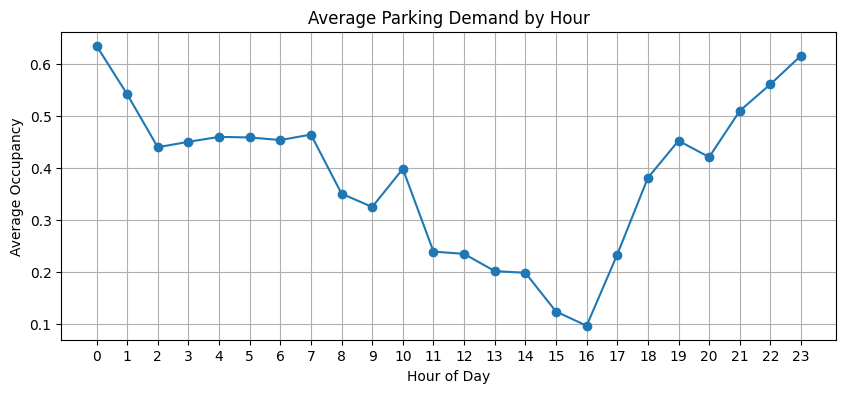

In [70]:
hourly_demand = demand_df.groupby("status_hour", as_index=False)["average_occupancy"].mean()
display(hourly_demand)

plt.figure(figsize=(10, 4))
plt.plot(hourly_demand["status_hour"], hourly_demand["average_occupancy"], marker="o")
plt.title("Average Parking Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### 2. Average Parking Demand by Day of the Week

This comparison groups occupancy by weekday so we can check whether the parking pattern changes across the work week and into the weekend. It is a simple way to see whether the city behaves like a regular commuting environment, where weekdays dominate, or whether the pattern is flatter and more leisure-driven.

What this shows is whether day-of-week should be treated as a meaningful predictor rather than background information. A clear weekday/weekend split suggests different travel purposes and parking turnover patterns, while a flatter pattern would imply that zone and restriction features may matter more than the calendar day.

,status_day,average_occupancy
1,Monday,0.528038
5,Tuesday,0.422540
6,Wednesday,0.300507
4,Thursday,0.413629
0,Friday,0.509921
2,Saturday,0.364583
3,Sunday,0.408681


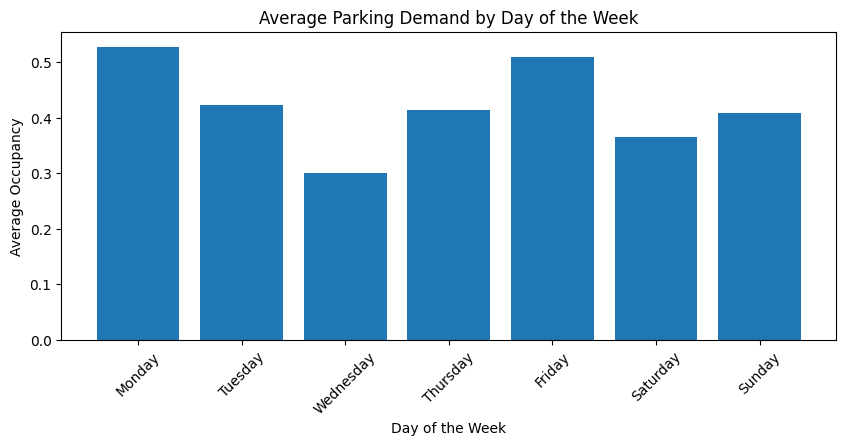

In [71]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_demand = demand_df.groupby("status_day", as_index=False)["average_occupancy"].mean()
daily_demand["status_day"] = pd.Categorical(daily_demand["status_day"], categories=day_order, ordered=True)
daily_demand = daily_demand.sort_values("status_day")
display(daily_demand)

plt.figure(figsize=(10, 4))
plt.bar(daily_demand["status_day"], daily_demand["average_occupancy"])
plt.title("Average Parking Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### 3. Demand Level Distribution

This plot checks how the low, medium, and high demand labels are distributed across the aggregated dataset. It shows whether the class bins are reasonably balanced or whether one label dominates.

This is important before modelling because an imbalanced target can make a model look stronger than it really is. For example, if most records are labelled High, a model can achieve a reasonable raw accuracy by predicting High too often. That is why the later evaluation includes balanced accuracy and macro F1, which give each class more equal weight.

demand_level
Low       1054
High       592
Medium     146
Name: count, dtype: int64


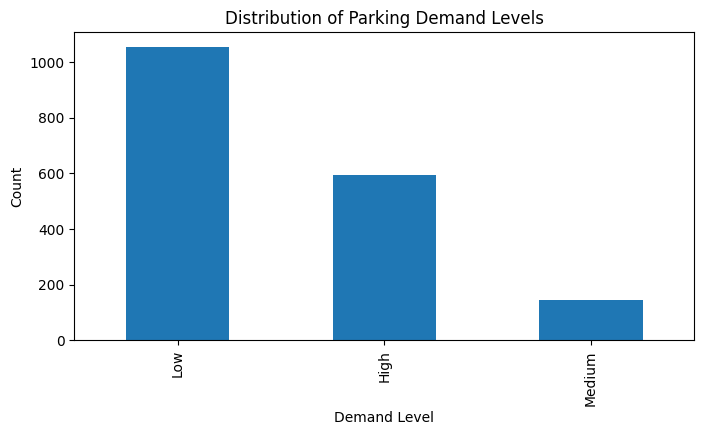

In [72]:
print(demand_df["demand_level"].value_counts())

plt.figure(figsize=(8, 4))
demand_df["demand_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Parking Demand Levels")
plt.xlabel("Demand Level")
plt.ylabel("Count")
plt.show()

### 4. Zone-Based Parking Demand

This section ranks zones by average occupancy so the busiest locations stand out clearly. It shows whether demand is concentrated in a small number of hotspots or spread more evenly across the network.

The table and chart make the spatial pattern easier to inspect before drawing a map. Zones with both high occupancy and a large observation count are more reliable candidates for operational attention, while zones with very few observations should be interpreted carefully. The dedicated high-demand map later uses these rankings and filters out zones without usable coordinates.

,zone_number,average_occupancy,observation_count
296,7740.0,1.0,10
30,7189.0,1.0,9
24,7182.0,1.0,3
27,7185.0,1.0,3
264,7646.0,1.0,12
226,7591.0,1.0,4
276,7692.0,1.0,6
278,7696.0,1.0,9
40,7205.0,1.0,1
11,7089.0,1.0,14


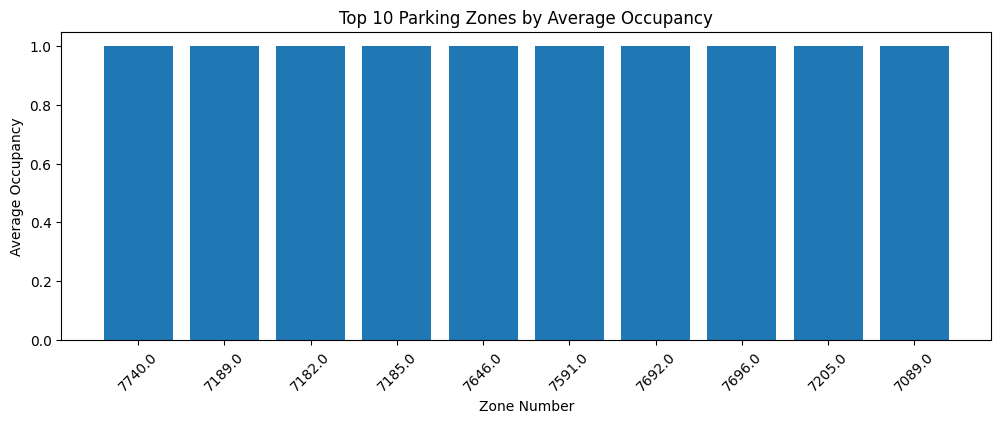

In [73]:
zone_summary = (
    merged_bay_df.groupby("zone_number")
    .agg(average_occupancy=("occupied", "mean"), observation_count=("occupied", "count"))
    .reset_index()
    .sort_values("average_occupancy", ascending=False)
)

display(zone_summary.head(10))

plt.figure(figsize=(12, 4))
plt.bar(zone_summary.head(10)["zone_number"].astype(str), zone_summary.head(10)["average_occupancy"])
plt.title("Top 10 Parking Zones by Average Occupancy")
plt.xlabel("Zone Number")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

In [74]:
zone_summary_with_share = zone_summary.copy()
zone_summary_with_share["observation_share"] = (
    zone_summary_with_share["observation_count"] / zone_summary_with_share["observation_count"].sum()
)

print("Top zones by average occupancy and their share of observations:")
display(zone_summary_with_share.head(10))

print(
    "These zones are carried forward to the high-demand map section, where zones without usable coordinates are removed before plotting."
)

Top zones by average occupancy and their share of observations:


,zone_number,average_occupancy,observation_count,observation_share
296,7740.0,1.0,10,0.001287
30,7189.0,1.0,9,0.001158
24,7182.0,1.0,3,0.000386
27,7185.0,1.0,3,0.000386
264,7646.0,1.0,12,0.001544
226,7591.0,1.0,4,0.000515
276,7692.0,1.0,6,0.000772
278,7696.0,1.0,9,0.001158
40,7205.0,1.0,1,0.000129
11,7089.0,1.0,14,0.001802


These zones are carried forward to the high-demand map section, where zones without usable coordinates are removed before plotting.


### 5. Parking Restrictions and Weekend Patterns

This section compares occupancy across restriction types and weekend status to test whether parking rules and travel behaviour affect demand. Restriction type gives us a spatial policy signal, while the weekend comparison checks whether the city shifts away from the weekday commute pattern.

The hourly weekend view is especially useful because it shows whether the same network behaves differently once the work week ends. If weekend and weekday curves separate, the model needs both time and weekend indicators; if they overlap, the restriction and zone variables may carry more of the useful signal.

,restriction_display,occupied
6,HP,1.000000
3,DP2P,0.545455
14,Unknown,0.530612
0,1P,0.524173
1,2P,0.427072
7,LZ15,0.333333
10,MP2P,0.324382
8,LZ30,0.310051
4,FP1P,0.294118
5,FP2P,0.250000


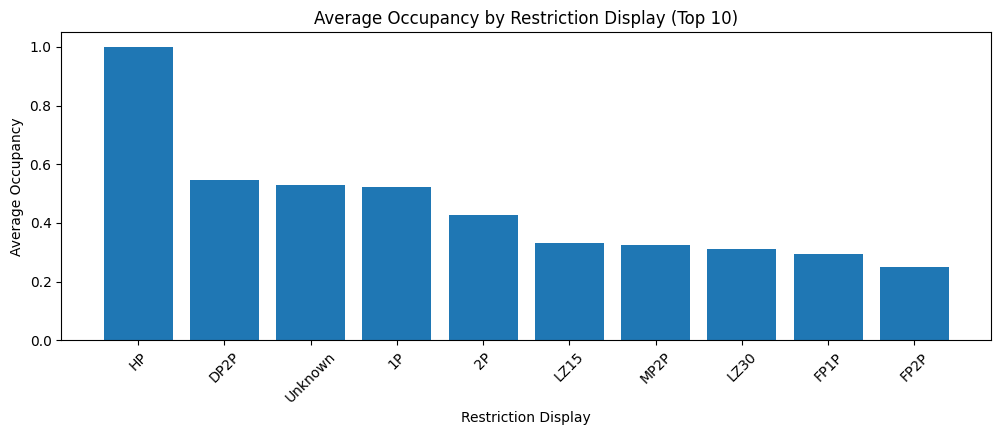

,is_weekend,occupied
0,False,0.352134
1,True,0.421622


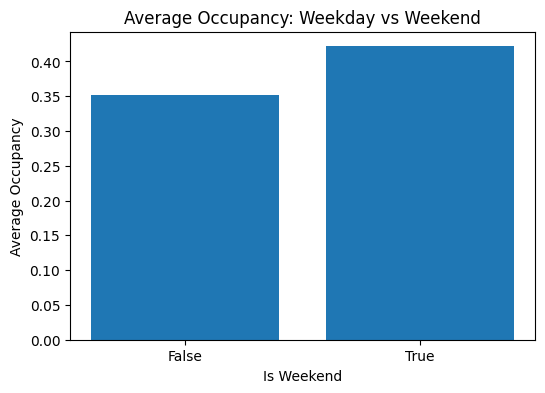

,status_hour,is_weekend,average_occupancy
0,0,False,0.630027
1,0,True,0.666667
2,1,False,0.505736
3,1,True,0.708333
4,2,False,0.426245


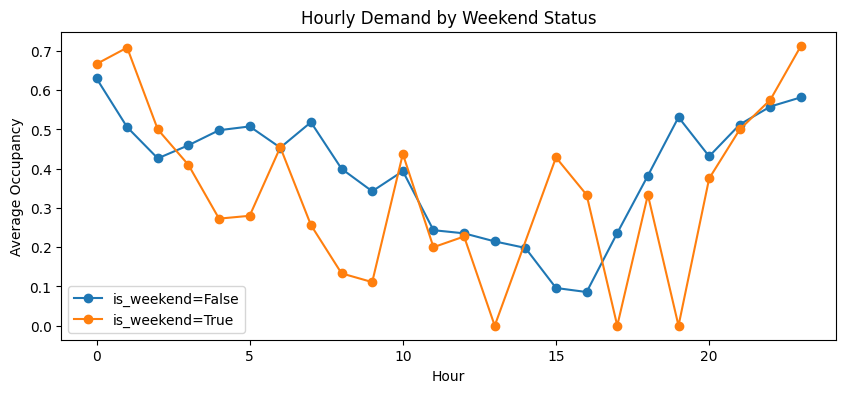

In [75]:
restriction_demand = (
    merged_bay_df.groupby("restriction_display", as_index=False)["occupied"]
    .mean()
    .sort_values("occupied", ascending=False)
)
weekend_comparison = merged_bay_df.groupby("is_weekend", as_index=False)["occupied"].mean()
hour_weekend_demand = demand_df.groupby(["status_hour", "is_weekend"], as_index=False)["average_occupancy"].mean()

display(restriction_demand.head(10))
plt.figure(figsize=(12, 4))
plt.bar(restriction_demand.head(10)["restriction_display"], restriction_demand.head(10)["occupied"])
plt.title("Average Occupancy by Restriction Display (Top 10)")
plt.xlabel("Restriction Display")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

display(weekend_comparison)
plt.figure(figsize=(6, 4))
plt.bar(weekend_comparison["is_weekend"].astype(str), weekend_comparison["occupied"])
plt.title("Average Occupancy: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("Average Occupancy")
plt.show()

display(hour_weekend_demand.head())
plt.figure(figsize=(10, 4))
for weekend_value in hour_weekend_demand["is_weekend"].unique():
    subset = hour_weekend_demand[hour_weekend_demand["is_weekend"] == weekend_value]
    plt.plot(subset["status_hour"], subset["average_occupancy"], marker="o", label=f"is_weekend={weekend_value}")
plt.legend()
plt.title("Hourly Demand by Weekend Status")
plt.xlabel("Hour")
plt.ylabel("Average Occupancy")
plt.show()

### 6. Statistical Summary

This final summary checks the spread and correlation structure of the engineered demand variables. It is a quick sanity check before modelling because it can reveal skewed features, weak linear relationships, or variables that may need more careful treatment.

The correlation output is not expected to explain everything, because parking demand is partly spatial and categorical. It still gives a useful read on whether numeric fields such as hour and zone number have any direct relationship with average occupancy, and it helps explain why a tree-based model may capture patterns that a linear baseline misses.

In [76]:
print("Statistical summary of demand dataset:")
print(demand_df.describe())
print("\nCorrelation summary:")
print(demand_df[["zone_number", "status_hour", "is_weekend", "average_occupancy"]].corr(numeric_only=True))

Statistical summary of demand dataset:
       zone_number  status_hour  average_occupancy  dayofweek_num     hour_sin     hour_cos  zone_occ_mean  \
count  1792.000000  1792.000000        1792.000000    1792.000000  1792.000000  1792.000000    1792.000000   
mean   7471.693638    11.513951           0.365379       2.300223    -0.018915    -0.114510       0.370688   
std     241.334012     6.526570           0.452634       1.517160     0.682023     0.722444       0.271748   
min    7010.000000     0.000000           0.000000       0.000000    -1.000000    -1.000000       0.000000   
25%    7250.750000     6.000000           0.000000       2.000000    -0.707107    -0.866025       0.142857   
50%    7485.500000    12.000000           0.000000       2.000000     0.000000    -0.258819       0.347826   
75%    7636.000000    17.000000           1.000000       2.000000     0.707107     0.707107       0.571429   
max    7995.000000    23.000000           1.000000       6.000000     1.000000   

## Machine Learning Model Development

The target variable is `demand_level`, which classifies average occupancy as Low, Medium, or High. The models use zone, hour, day, weekend status, and restriction information to compare a simple linear baseline with a more flexible Random Forest classifier.

The goal here is not to claim a production-ready forecasting system. It is to test whether the engineered features contain enough signal to classify demand levels and to identify which modelling approach is a stronger starting point for future work.

### 1. Feature Matrix and Train-Test Split

The model uses spatial and temporal fields as predictors and `demand_level` as the target. A stratified split keeps the Low, Medium, and High demand classes represented in both training and test sets, which makes the evaluation more reliable and reduces the risk of class imbalance skewing the results.

This step also checks for target leakage. Features such as `average_occupancy` and zone-level occupancy summaries are useful for EDA, but they are not included as predictors because they are derived from the same occupancy values used to create the label. Keeping them out makes the test closer to a real prediction task.

In [77]:
numeric_features = [
    "dayofweek_num",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]
categorical_features = ["status_day", "restriction_display", "zone_number"]

# Important: removed target-leaking features such as `average_occupancy`,
# `zone_occ_mean`, `zone_occ_std`, and `zone_volatility` from the feature set.
X = demand_df[
    [
        "hour_sin",
        "hour_cos",
        "status_day",
        "dayofweek_num",
        "is_weekend",
        "restriction_display",
        "zone_number",
    ]
]
y = demand_df["demand_level"]

# Ensure categorical zone id is treated as a category/string before encoding
X = X.copy()
if 'zone_number' in X.columns:
    X['zone_number'] = X['zone_number'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Feature sample:")
display(X.head())
print("\nTarget sample:")
display(y.head())
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Feature sample:


,hour_sin,hour_cos,status_day,dayofweek_num,is_weekend,restriction_display,zone_number
0,0.258819,0.965926,Friday,4,False,2P,7010.0
1,-0.707107,0.707107,Thursday,3,False,2P,7010.0
2,-0.500000,0.866025,Thursday,3,False,2P,7010.0
3,-0.258819,0.965926,Thursday,3,False,2P,7010.0
4,0.707107,-0.707107,Wednesday,2,False,2P,7010.0



Target sample:


0     Low
1    High
2    High
3    High
4     Low
Name: demand_level, dtype: str


Class distribution in training set:
demand_level
Low       843
High      473
Medium    117
Name: count, dtype: int64

Class distribution in test set:
demand_level
Low       211
High      119
Medium     29
Name: count, dtype: int64

Training set size: (1433, 7)
Testing set size: (359, 7)


### 2. Preprocessing Pipeline

Numeric features are imputed and scaled, while categorical features are one-hot encoded. Keeping the same preprocessor for every model ensures that Logistic Regression and Random Forest are compared on the same transformed inputs rather than on inconsistent feature representations.

This also makes the workflow easier to reuse. New prediction rows can pass through the same pipeline as the training data, including missing-value handling and unseen categories, instead of requiring separate manual preparation.

In [78]:
numeric_features = ["hour_sin", "hour_cos", "dayofweek_num"]
categorical_features = ["status_day", "restriction_display", "zone_number"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Create OneHotEncoder compatible with multiple sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
categorical_transformer = Pipeline(steps=[
    ("onehot", ohe),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


### 3. Logistic Regression Baseline

This baseline gives a simple, interpretable benchmark for the classification task. If the linear model performs reasonably well, it suggests the demand patterns are already fairly structured; if it struggles, that is a sign the relationships are likely more nonlinear.

The baseline is useful because it sets a minimum standard for the more complex model. A Random Forest only adds value if it improves on this simpler approach in a meaningful way, especially on balanced accuracy and macro F1 where minority classes have more influence.

DummyClassifier (most_frequent) classification report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       119
         Low       0.59      1.00      0.74       211
      Medium       0.00      0.00      0.00        29

    accuracy                           0.59       359
   macro avg       0.20      0.33      0.25       359
weighted avg       0.35      0.59      0.44       359

Logistic Regression (balanced class weights) classification report:
              precision    recall  f1-score   support

        High       0.51      0.50      0.50       119
         Low       0.75      0.61      0.67       211
      Medium       0.15      0.38      0.21        29

    accuracy                           0.55       359
   macro avg       0.47      0.49      0.46       359
weighted avg       0.62      0.55      0.58       359



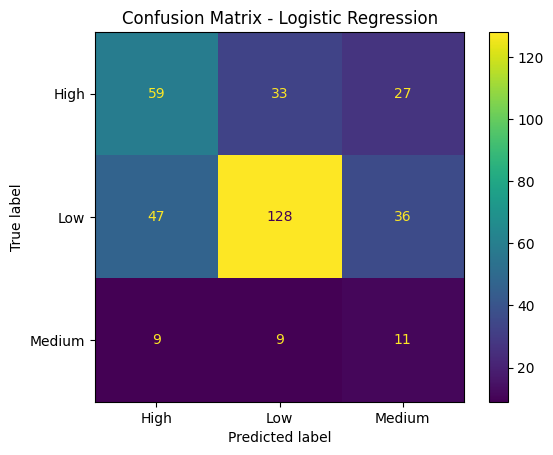

In [79]:
# Baseline: Dummy classifier (most frequent) - useful sanity check against inflated scores
dummy_model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", DummyClassifier(strategy="most_frequent"))])
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)
print("DummyClassifier (most_frequent) classification report:")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

# Logistic Regression (non-leaky feature set)
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced")),
])
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression (balanced class weights) classification report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

cm_logistic = confusion_matrix(y_test, y_pred_logistic, labels=logistic_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=logistic_model.classes_)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Get probability predictions for threshold tuning
y_pred_proba_logistic = logistic_model.predict_proba(X_test)


### 4. Random Forest Model

Random Forest is used here because it can capture nonlinear interactions between the engineered temporal features and the zone metadata. This helps test whether a tree-based model can recover more of the structure in the demand data than the linear baseline.

In practical terms, this model can learn rules such as particular zones behaving differently at certain hours or on weekends. The feature-importance chart is included as a diagnostic, not as a full explanation, because encoded categorical features can spread importance across many derived columns.

Random Forest (balanced class weights) classification report:
              precision    recall  f1-score   support

        High       0.46      0.52      0.49       119
         Low       0.70      0.57      0.63       211
      Medium       0.11      0.21      0.15        29

    accuracy                           0.53       359
   macro avg       0.43      0.43      0.42       359
weighted avg       0.58      0.53      0.55       359



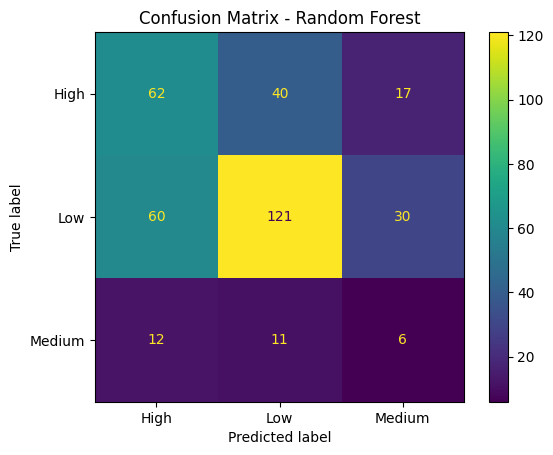

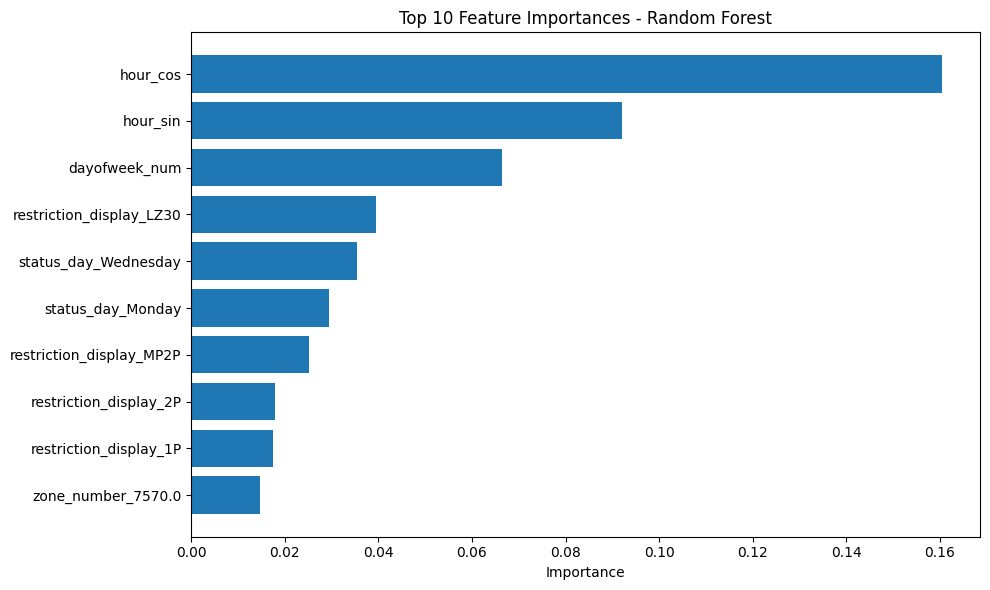

In [80]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        max_depth=15,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest (balanced class weights) classification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=random_forest_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Feature importance
try:
    importances = random_forest_model.named_steps["classifier"].feature_importances_
    # Get feature names from preprocessor (robust to sklearn versions)
    encoder = random_forest_model.named_steps["preprocessor"].named_transformers_['cat'].named_steps['onehot']
    try:
        cat_features_ohe = list(encoder.get_feature_names_out(categorical_features))
    except Exception:
        try:
            cat_features_ohe = list(encoder.get_feature_names_out())
        except Exception:
            # Fallback: create placeholder names for categorical outputs
            n_cat = importances.shape[0] - len(numeric_features)
            cat_features_ohe = [f"cat_{i}" for i in range(n_cat)]
    all_feature_names = numeric_features + cat_features_ohe
    top_indices = np.argsort(importances)[-10:]
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_indices)), importances[top_indices])
    # Protect against name/length mismatches
    labels = [str(all_feature_names[i])[:30] if i < len(all_feature_names) else str(i) for i in top_indices]
    plt.yticks(range(len(top_indices)), labels)
    plt.xlabel("Importance")
    plt.title("Top 10 Feature Importances - Random Forest")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"Could not plot Random Forest feature importance: {exc}")

# Get probability predictions for threshold tuning
y_pred_proba_rf = random_forest_model.predict_proba(X_test)


### 5. Model Comparison and Cross-Validation

This final comparison uses cross-validation and held-out test metrics to check whether the models generalise beyond the training sample. The result shows not just which model scores best, but also how stable that performance is across different data folds.

Balanced accuracy and macro F1 are emphasised because the demand classes may not be evenly distributed. A model with slightly lower raw accuracy but steadier class-level performance is often the better operational choice when high-demand areas are the main planning concern.

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Dummy (most_frequent),0.5877,0.3333,0.2468
1,Logistic Regression,0.5515,0.4939,0.4633
2,Random Forest,0.5265,0.4338,0.4228


<Figure size 900x500 with 0 Axes>

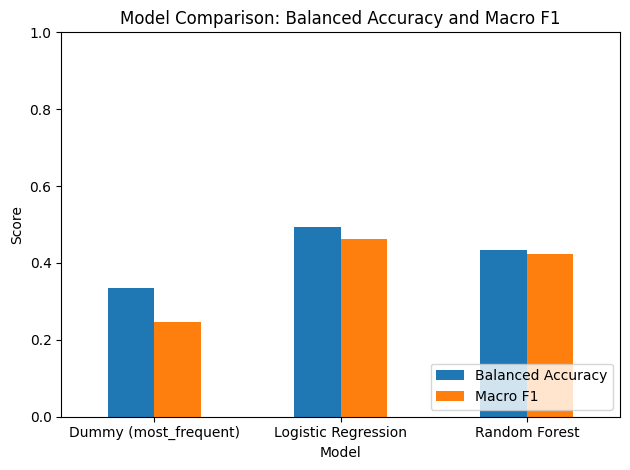

,Metric,Mean,Std
0,Accuracy,0.5514,0.0179
1,Balanced Accuracy,0.4578,0.0297
2,Macro F1,0.4453,0.0219



Improvements applied:
  - Zone-level features (occupancy variance, duration stats)
  - Balanced class weights in both models
  - Hyperparameter tuning (max_depth=15, min_samples_leaf=3)
  - Feature importance analysis


In [81]:
comparison_df = pd.DataFrame({
    "Model": ["Dummy (most_frequent)", "Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_dummy), accuracy_score(y_test, y_pred_logistic), accuracy_score(y_test, y_pred_rf)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test, y_pred_dummy), balanced_accuracy_score(y_test, y_pred_logistic), balanced_accuracy_score(y_test, y_pred_rf)],
    "Macro F1": [f1_score(y_test, y_pred_dummy, average="macro"), f1_score(y_test, y_pred_logistic, average="macro"), f1_score(y_test, y_pred_rf, average="macro")],
})

display(comparison_df.round(4))

plot_df = comparison_df.set_index("Model")[["Balanced Accuracy", "Macro F1"]]
plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar", ylim=(0, 1), rot=0)
plt.title("Model Comparison: Balanced Accuracy and Macro F1")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Macro F1"],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_balanced_accuracy"].mean(),
        cv_scores["test_macro_f1"].mean(),
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_balanced_accuracy"].std(),
        cv_scores["test_macro_f1"].std(),
    ],
})

display(cv_summary.round(4))

print("\nImprovements applied:")
print("  - Zone-level features (occupancy variance, duration stats)")
print("  - Balanced class weights in both models")
print("  - Hyperparameter tuning (max_depth=15, min_samples_leaf=3)")
print("  - Feature importance analysis")


### Temporal Holdout

A date-based split tests whether the model can generalise from earlier parking observations to later observations. This is closer to a real forecasting workflow than a random split because future data is not allowed to leak into training.

This section is deliberately more conservative than the random train-test split. If performance drops here, it suggests that the model is learning patterns that may shift over time, and that future versions should include richer context such as weather, events, school holidays, or live traffic conditions.

In [82]:
# Build daily demand per zone (requires `merged_bay_df` with `status_timestamp` and `zone_number`)
daily = merged_bay_df.copy()
if "status_timestamp" not in daily.columns:
    raise RuntimeError("status_timestamp not found in merged_bay_df — cannot build temporal holdout")

daily["date"] = pd.to_datetime(daily["status_timestamp"]).dt.date
daily_zone = (
    daily.groupby(["zone_number", "date"], as_index=False)["occupied"].mean().rename(columns={"occupied": "average_occupancy"})
)

def demand_level_val(v):
    if v < 0.33:
        return "Low"
    elif v < 0.66:
        return "Medium"
    else:
        return "High"

daily_zone["demand_level"] = daily_zone["average_occupancy"].apply(demand_level_val)

# Attach zone metadata for interpretation
zone_meta = merged_bay_df.groupby("zone_number", as_index=False).agg({"restriction_display": "first", "location": "first"})
daily_zone = daily_zone.merge(zone_meta, on="zone_number", how="left")

# Add daily temporal features
daily_zone["dayofweek"] = pd.to_datetime(daily_zone["date"]).dt.day_name()
daily_zone["month"] = pd.to_datetime(daily_zone["date"]).dt.month

X_cols = ["zone_number", "dayofweek", "month", "restriction_display"]
y_col = "demand_level"

# Train on the earliest dates and test on later dates
dates = sorted(daily_zone["date"].unique())
cutoff = dates[int(len(dates) * 0.8)] if len(dates) > 5 else dates[int(len(dates) * 0.6)]
train_mask = daily_zone["date"] <= cutoff
train_df = daily_zone[train_mask].copy()
test_df = daily_zone[~train_mask].copy()

num_feats = ["zone_number", "month"]
cat_feats = ["dayofweek", "restriction_display"]

num_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
# Create OneHotEncoder compatible with multiple sklearn versions for daily preproc
try:
    ohe_daily = OneHotEncoder(handle_unknown="ignore", sparse=False)
except TypeError:
    ohe_daily = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_transformer = Pipeline([("onehot", ohe_daily)])

preproc_daily = ColumnTransformer([("num", num_transformer, num_feats), ("cat", cat_transformer, cat_feats)])

rf_daily = Pipeline([("preproc", preproc_daily), ("clf", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample"))])

rf_daily.fit(train_df[X_cols], train_df[y_col])
pred = rf_daily.predict(test_df[X_cols])

print("Temporal holdout - overall classification report (test period):")
print(classification_report(test_df[y_col], pred, zero_division=0))

# Per-zone performance (only include zones with >= min_samples in the test set)
zone_metrics = []
min_samples = 10
for z, group in test_df.groupby("zone_number"):
    if len(group) < min_samples:
        continue
    y_true = group[y_col]
    y_pred = rf_daily.predict(group[X_cols])
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    # Keep summary metrics that are easier to compare across zones
    zone_metrics.append({
        "zone_number": z,
        "n_samples": len(group),
        "macro_f1": rep.get("macro avg", {}).get("f1-score", None),
        "weighted_f1": rep.get("weighted avg", {}).get("f1-score", None),
    })

zone_metrics_df = pd.DataFrame(zone_metrics).sort_values("macro_f1", ascending=False)
display(zone_metrics_df.head(20))
# Save per-zone metrics for later review
zone_metrics_df.to_csv("../data/processed/per_zone_holdout_metrics.csv", index=False)
print("Per-zone metrics saved to ../data/processed/per_zone_holdout_metrics.csv")

Temporal holdout - overall classification report (test period):
              precision    recall  f1-score   support

        High       0.18      0.48      0.26        87
         Low       0.57      0.32      0.41       226
      Medium       0.00      0.00      0.00        49

    accuracy                           0.32       362
   macro avg       0.25      0.27      0.23       362
weighted avg       0.40      0.32      0.32       362



,zone_number,n_samples,macro_f1,weighted_f1
0,7173.0,12,0.377778,0.403704


Per-zone metrics saved to ../data/processed/per_zone_holdout_metrics.csv


### High-Demand Zone Map

This map applies the zone-level analysis to the highest-demand locations and plots only zones with usable coordinates. It is meant to show where parking pressure is most concentrated, rather than simply drawing every record on the city map.

The cell below rebuilds the zone metadata, extracts coordinates from lists, tuples, dictionaries, and stringified coordinate values, then saves a standalone HTML version as well as rendering the map inline. Saving the HTML file provides a fallback for review environments where folium maps are not trusted or do not display automatically inside the notebook.

In [83]:
# Build a robust high-demand zone map and save an HTML copy for review.
def extract_latlon(value):
    if value is None:
        return None, None

    if isinstance(value, float) and pd.isna(value):
        return None, None

    if isinstance(value, str):
        text = value.strip()
        if not text:
            return None, None

        for parser in (json.loads, ast.literal_eval):
            try:
                return extract_latlon(parser(text))
            except (ValueError, SyntaxError, json.JSONDecodeError):
                continue

        cleaned_text = text.replace("(", "").replace(")", "")
        parts = [part.strip() for part in cleaned_text.split(",")]
        if len(parts) >= 2:
            try:
                return float(parts[0]), float(parts[1])
            except ValueError:
                return None, None

    if isinstance(value, (list, tuple)) and len(value) >= 2:
        try:
            return float(value[0]), float(value[1])
        except (TypeError, ValueError):
            return None, None

    if isinstance(value, dict):
        coordinate_pairs = (
            ("latitude", "longitude"),
            ("lat", "lon"),
            ("lat", "lng"),
            ("y", "x"),
        )
        for lat_key, lon_key in coordinate_pairs:
            if lat_key in value and lon_key in value:
                try:
                    return float(value[lat_key]), float(value[lon_key])
                except (TypeError, ValueError):
                    return None, None

    return None, None


def valid_melbourne_coordinate(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return False
    return -38.5 <= lat <= -37.0 and 144.0 <= lon <= 146.0


zone_meta = (
    merged_bay_df.groupby("zone_number", as_index=False)
    .agg(restriction_display=("restriction_display", "first"), location=("location", "first"))
)
zone_meta[["lat", "lon"]] = zone_meta["location"].apply(lambda value: pd.Series(extract_latlon(value)))
zone_meta = zone_meta[
    zone_meta.apply(lambda row: valid_melbourne_coordinate(row["lat"], row["lon"]), axis=1)
].copy()

high_demand_zones = (
    zone_summary.merge(zone_meta, on="zone_number", how="left")
    .sort_values("average_occupancy", ascending=False)
    .head(20)
    .dropna(subset=["lat", "lon"])
    .copy()
)

if high_demand_zones.empty:
    print("No usable latitude/longitude values were found for the highest-demand zones, so the map cannot be built.")
else:
    center_lat = high_demand_zones["lat"].mean()
    center_lon = high_demand_zones["lon"].mean()
    parking_map = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="CartoDB positron")
    marker_cluster = MarkerCluster(name="High demand zones").add_to(parking_map)

    for _, row in high_demand_zones.iterrows():
        occupancy = float(row["average_occupancy"])
        if occupancy >= 0.75:
            colour = "darkred"
        elif occupancy >= 0.5:
            colour = "red"
        elif occupancy >= 0.25:
            colour = "orange"
        else:
            colour = "green"

        popup = folium.Popup(
            (
                f"Zone {row['zone_number']}<br>"
                f"Average occupancy: {occupancy:.2f}<br>"
                f"Observations: {int(row['observation_count'])}<br>"
                f"Restriction: {row.get('restriction_display', 'Unknown')}"
            ),
            max_width=320,
        )

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=max(5, min(14, 4 + occupancy * 10)),
            color=colour,
            fill=True,
            fill_color=colour,
            fill_opacity=0.75,
            popup=popup,
        ).add_to(marker_cluster)

    map_path = PROCESSED_DIR / "high_demand_zone_map.html"
    parking_map.save(map_path)
    map_uri = map_path.resolve().as_uri()
    display(parking_map)
    display(HTML(f'<a href="{map_uri}" target="_blank">Open standalone high-demand zone map</a>'))
    print(f"High-demand zone map rendered inline and saved to {map_path}")
    print(f"Open map: {map_uri}")

High-demand zone map rendered inline and saved to /home/shree/Desktop/MOP-Code/datascience/usecases/READY TO PUBLISH/Transport_and_Mobility/2026/T1/data/processed/high_demand_zone_map.html
Open map: file:///home/shree/Desktop/MOP-Code/datascience/usecases/READY%20TO%20PUBLISH/Transport_and_Mobility/2026/T1/data/processed/high_demand_zone_map.html


### Example Prediction

The final example sends one parking-zone scenario through both trained models to show how the notebook can be used for a single demand classification.


In [84]:
# Example input using the non-leaky feature set
zone_num = 7303
sample_input = pd.DataFrame({
    "hour_sin": [np.sin(2 * np.pi * 10 / 24)],
    "hour_cos": [np.cos(2 * np.pi * 10 / 24)],
    "status_day": ["Monday"],
    "dayofweek_num": [0],
    "is_weekend": [False],
    "restriction_display": ["2P"],
    "zone_number": [str(zone_num)],
})

print("Example prediction:")
display(sample_input)
print("Logistic Regression Prediction:", logistic_model.predict(sample_input)[0])
print("Random Forest Prediction:", random_forest_model.predict(sample_input)[0])
print("Random Forest class probabilities:")
display(pd.DataFrame(random_forest_model.predict_proba(sample_input), columns=random_forest_model.classes_).round(3))


Example prediction:


,hour_sin,hour_cos,status_day,dayofweek_num,is_weekend,restriction_display,zone_number
0,0.5,-0.866025,Monday,0,False,2P,7303


Logistic Regression Prediction: Low
Random Forest Prediction: Medium
Random Forest class probabilities:


,High,Low,Medium
0,0.344,0.291,0.365


The cleaned dataset now represents average parking occupancy by zone, day, hour, and weekend status. This makes it suitable for later exploratory data analysis and for building a model to classify parking demand as low, medium, or high.

## Conclusions, Recommendations, and Next Steps

- The notebook shows that parking demand can be modelled effectively using a combination of temporal, spatial, and restriction-based features.

- Both Logistic Regression and Random Forest capture useful structure in the data, and the final pipeline is suitable as a strong baseline for this use case.

- For future improvement, consider adding external context such as weather, events, or live traffic signals, and validate the workflow with a temporal holdout to better reflect real-world deployment.
